# Fill styles for interpretation outputs

`pphys.onepage` ships ready-made fill styles for the intervals a petrophysicist shades on a log or a section:

| Table | For |
|---|---|
| `Lithology` | rock types, following the common graphic lithology key |
| `Mineral` | minerals in multimineral volume tracks |
| `Porespace` | pore volumes and fluids in porosity and saturation tracks |

A style (`FillStyle`) is a face colour, an optional matplotlib hatch and optional *motifs*: repeated symbols such as limestone bricks or chert triangles. Motif sizes are in points, so a pattern looks the same on any track, whatever its depth range.

In [1]:
import dataclasses

import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

from pphys import read
from pphys.onepage import (
    FillStyle,
    Lithology,
    Mineral,
    MotifPattern,
    Motifs,
    Pigment,
    Porespace,
    StyleTable,
    WellView,
)

## 1. Graphic lithology key

`plot_key()` draws a labelled swatch per style. Pass a list of rows to control the layout; shorter rows are centred. The swatches use the same point-sized symbols as the log plots, so the key matches what the tracks show.

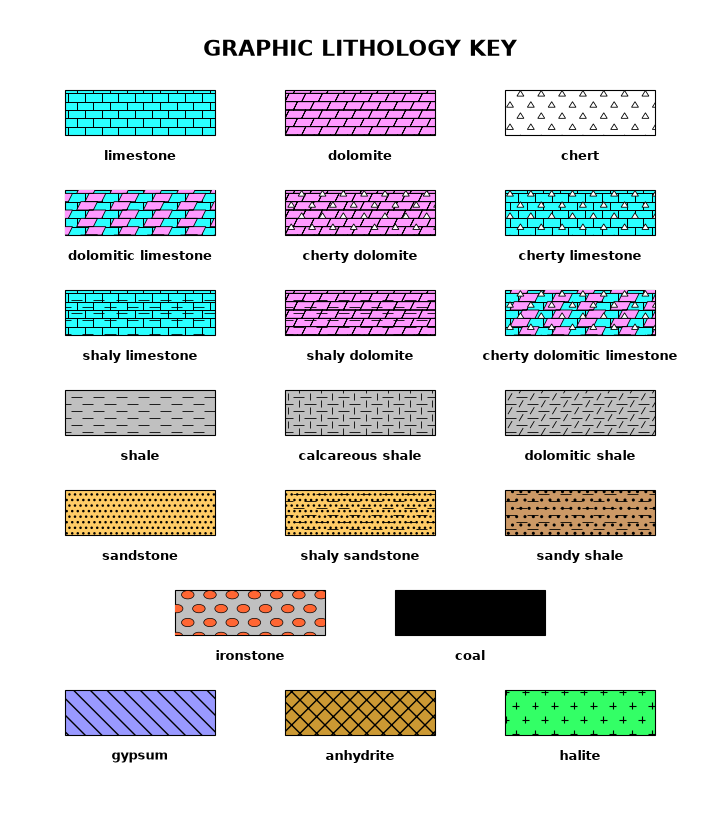

In [2]:
key = [
    ["limestone", "dolomite", "chert"],
    ["dolomitic limestone", "cherty dolomite", "cherty limestone"],
    ["shaly limestone", "shaly dolomite", "cherty dolomitic limestone"],
    ["shale", "calcareous shale", "dolomitic shale"],
    ["sandstone", "shaly sandstone", "sandy shale"],
    ["ironstone", "coal"],
    ["gypsum", "anhydrite", "halite"],
]
fig = Lithology.plot_key(key, title="GRAPHIC LITHOLOGY KEY")

The table also holds classes used in interpretation outputs (`matrix`, `shale free`) and `salt` as a synonym of halite:

In [3]:
Lithology.names()

('limestone',
 'dolomite',
 'chert',
 'dolomitic_limestone',
 'cherty_dolomite',
 'cherty_limestone',
 'shaly_limestone',
 'shaly_dolomite',
 'cherty_dolomitic_limestone',
 'shale',
 'calcareous_shale',
 'dolomitic_shale',
 'sandstone',
 'shaly_sandstone',
 'sandy_shale',
 'ironstone',
 'coal',
 'gypsum',
 'anhydrite',
 'halite',
 'salt',
 'matrix',
 'shale_free')

## 2. What a style holds

Look a style up by name. Case, spaces, hyphens and underscores do not matter, and attribute access works too. A misspelt name raises a `KeyError` with suggestions.

In [4]:
style = Lithology["Cherty Dolomitic Limestone"]
style is Lithology.cherty_dolomitic_limestone

True

In [5]:
print("facecolor:", style.facecolor)
print("hatch:    ", style.hatch)
print("motifs:   ", len(style.motifs))
print("label:    ", style.label)

facecolor: #2BFFFF
hatch:     None
motifs:    3
label:     cherty dolomitic limestone


In [6]:
try:
    Lithology["limstone"]
except KeyError as error:
    print(error)

"No style 'limstone' in Graphic lithology key. Did you mean limestone, ironstone, shaly_limestone?"


A style unpacks like a dict into `facecolor`, `hatch`, `motifs` and `label`, which is what the fill functions take: `Pigment.fill_solid(..., **Lithology.limestone)`, `WellView.add_module(..., **Mineral.quartz)` and `CrossView.add_formation(..., **Lithology.shale)`.

In [7]:
dict(**Lithology.sandstone)

{'facecolor': '#FFCC66', 'hatch': '...', 'motifs': (), 'label': 'sandstone'}

A table can be summarized as a DataFrame to see how each style is built:

In [8]:
motif_names = {id(motif): name for name, motif in Motifs.items()}


def describe(table):
    return pd.DataFrame(
        [
            {
                "style": style.label,
                "facecolor": style.facecolor,
                "hatch": style.hatch or "",
                "motifs": ", ".join(motif_names.get(id(m), "custom") for m in style.motifs),
            }
            for _, style in table.items()
        ]
    )


describe(Lithology)

,style,facecolor,hatch,motifs
0,limestone,#2BFFFF,,brick
1,dolomite,#FF99FF,,rhomb
2,chert,white,,chert
3,dolomitic limestone,#2BFFFF,,"brick, custom"
4,cherty dolomite,#FF99FF,,"rhomb, chert"
5,cherty limestone,#2BFFFF,,"brick, chert"
6,shaly limestone,#2BFFFF,,"brick, shale"
7,shaly dolomite,#FF99FF,,"rhomb, shale"
8,cherty dolomitic limestone,#2BFFFF,,"brick, custom, chert"
9,shale,#C0C0C0,,shale


Mixed lithologies combine the symbols of their parts: shaly limestone adds shale dashes to limestone bricks, calcareous and dolomitic shale add vertical or slanted joints between the dashes, and dolomitic limestone replaces every other brick with a pink, leaning dolomite brick (the `custom` motif above).

## 3. Minerals and pore space

`Mineral` holds styles for multimineral volume tracks and `Porespace` for porosity and saturation tracks (bound and free water, oil and gas, residual and movable fractions).

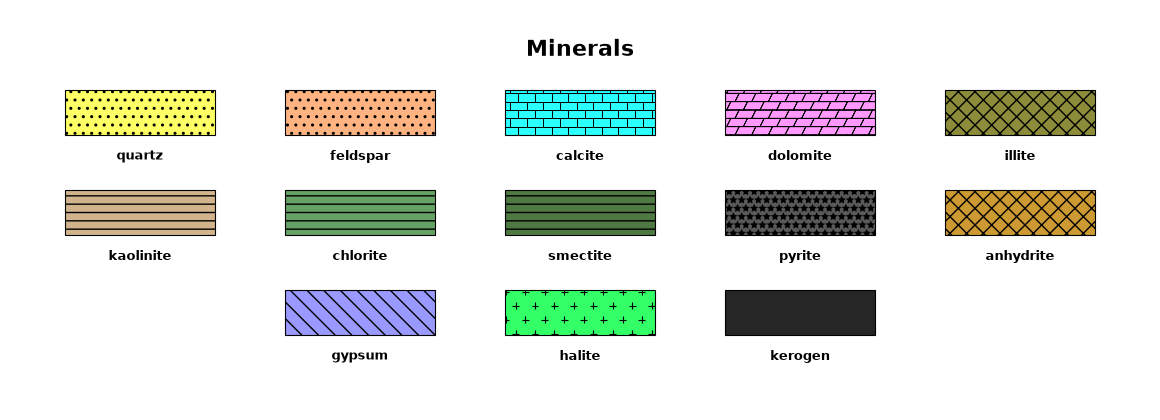

In [9]:
fig = Mineral.plot_key(ncols=5)

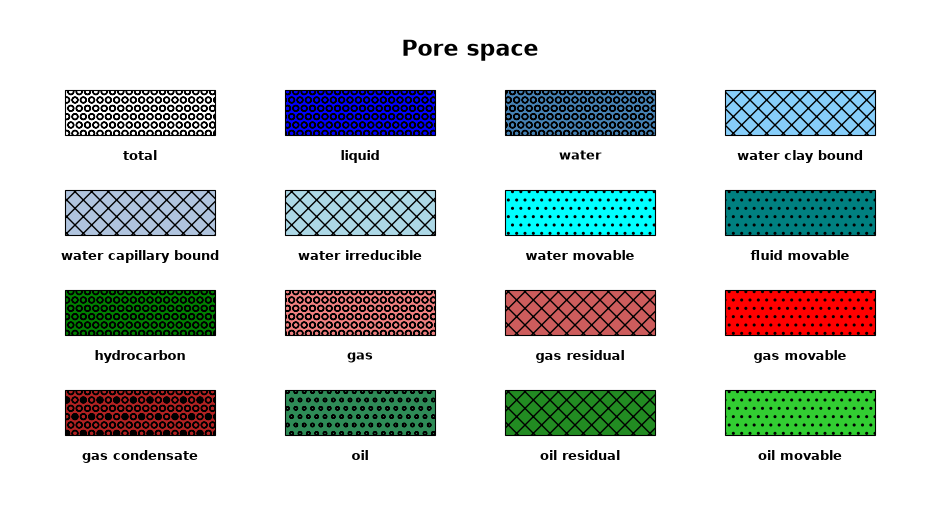

In [10]:
fig = Porespace.plot_key(ncols=4)

In [11]:
describe(Porespace)

,style,facecolor,hatch,motifs
0,total,white,OO,
1,liquid,blue,OO,
2,water,steelblue,OO,
3,water clay bound,lightskyblue,XX,
4,water capillary bound,lightsteelblue,XX,
5,water irreducible,lightblue,XX,
6,water movable,aqua,..,
7,fluid movable,teal,..,
8,hydrocarbon,green,OO,
9,gas,lightcoral,OO,


## 4. Motifs: the building blocks

`Motifs` holds the predefined symbols. Each is a `MotifPattern`: a shape (`circle`, `ellipse`, `line`, `cross`, `triangle` or `quadrilateral`) repeated on a grid, with every other row staggered. Sizes are in points.

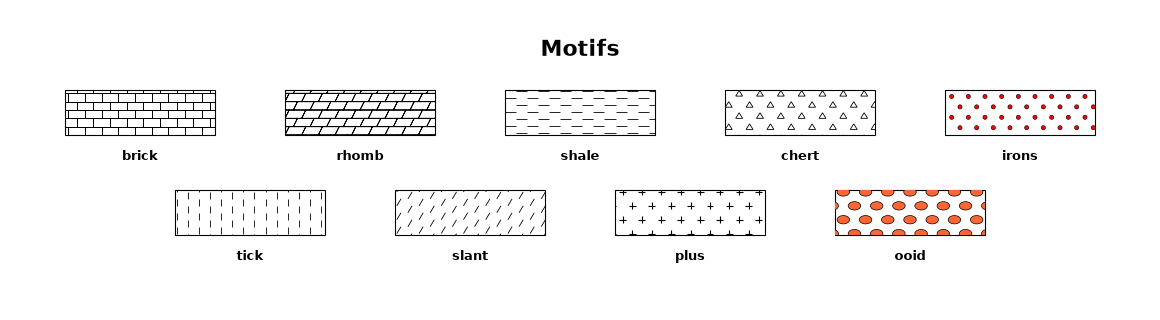

In [12]:
motif_key = StyleTable("Motifs", {name: FillStyle(motifs=(motif,)) for name, motif in Motifs.items()})
fig = motif_key.plot_key(ncols=5)

In [13]:
pd.DataFrame(
    [
        {
            "motif": name,
            "element": motif.element,
            "size (pt)": f"{motif.length:g} x {motif.height:g}",
            "cell (pt)": f"{motif.length_extern:g} x {motif.height_extern:g}",
            "row stagger": motif.offset_ratio,
            "tilt": motif.tilted_ratio,
        }
        for name, motif in Motifs.items()
    ]
)

,motif,element,size (pt),cell (pt),row stagger,tilt
0,brick,quadrilateral,12 x 6,12 x 6,0.5,0.00
1,rhomb,quadrilateral,12 x 6,12 x 6,0.5,0.25
2,shale,line,8 x 0,16 x 5,0.5,0.00
3,chert,triangle,5 x 4,15 x 8,0.5,0.00
4,irons,circle,3 x 3,12 x 7.5,0.5,0.00
5,tick,line,0 x 5,16 x 5,0.5,0.00
6,slant,line,3 x 5,16 x 5,0.5,0.00
7,plus,cross,5 x 5,14 x 10,0.5,0.00
8,ooid,ellipse,9 x 6,16 x 10,0.5,0.00


## 5. Custom styles

Styles are immutable; derive a variant with `dataclasses.replace`, or build new ones from motifs. Here, a bioclastic limestone with shell fragments and a glauconitic sandstone. Put them in a `StyleTable` to look them up by name and draw a key.

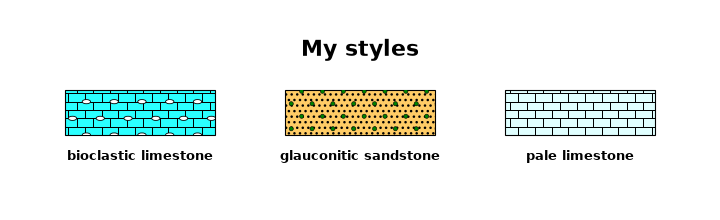

In [14]:
shells = MotifPattern(
    "ellipse",
    length=6.0,
    height=3.0,
    length_extern=20.0,
    height_extern=12.0,
    shift_ratio=0.25,
    params={"edgecolor": "black", "facecolor": "white", "linewidth": 0.6},
)
glauconite = MotifPattern(
    "circle",
    length=3.0,
    height=3.0,
    length_ratio=5.0,
    height_ratio=3.0,
    params={"edgecolor": "black", "facecolor": "green", "linewidth": 0.4},
)

my_styles = StyleTable(
    "My styles",
    {
        "bioclastic limestone": FillStyle(
            Lithology.limestone.facecolor, motifs=(*Lithology.limestone.motifs, shells)
        ),
        "glauconitic sandstone": dataclasses.replace(
            Lithology.sandstone, motifs=(glauconite,), label=""
        ),
        "pale limestone": dataclasses.replace(
            Lithology.limestone, facecolor="lightcyan", label=""
        ),
    },
)
fig = my_styles.plot_key()

## 6. In a well log

`tutorial_1_graph_B.LAS` has gamma ray, photoelectric factor (PE) and density. The cell below derives an **illustrative** interpretation from textbook relations, only to have something to shade:

- shale volume from a linear gamma-ray index;
- dolomite share from PE (limestone 5.08, dolomite 3.14 b/e);
- total porosity from density with a limestone matrix (2.71 g/cc);
- a lithology class per sample from shale volume and dolomite share;
- mineral and fluid volumes, with an assumed water saturation (there is no resistivity log in this file).

In [15]:
log = read("tutorial_1_graph_B.LAS")
depth = log.index
frame = log.df().rolling(21, center=True, min_periods=1).median()  # ~1 m

gr, pe, rhob = frame["GAMMATOTAL"], frame["PE"], frame["DENSITY"]
vsh = ((gr - gr.quantile(0.05)) / (gr.quantile(0.95) - gr.quantile(0.05))).clip(0, 1)
dolomite_share = ((5.08 - pe) / (5.08 - 3.14)).clip(0, 1)
phit = ((2.71 - rhob) / (2.71 - 1.0)).clip(0, 0.35)


def lithology_of(vsh, dol):
    if vsh >= 0.5:
        return "shale"
    if vsh >= 0.25:
        return "shaly dolomite" if dol >= 0.5 else "shaly limestone"
    if dol >= 0.66:
        return "dolomite"
    if dol >= 0.33:
        return "dolomitic limestone"
    return "limestone"


classes = pd.Series([lithology_of(v, d) for v, d in zip(vsh, dolomite_share)], index=frame.index)
change = classes.ne(classes.shift()).cumsum()
zones = [(group.index.min(), group.index.max(), group.iloc[0]) for _, group in classes.groupby(change)]

# Volumes as fractions of the bulk volume (they add up to 1).
illite = 0.6 * vsh * (1 - phit)
carbonate = (1 - phit) - illite
dolomite, calcite = carbonate * dolomite_share, carbonate * (1 - dolomite_share)
bound_water = phit * (0.8 * vsh).clip(0, 1)
sw = (0.35 + 0.6 * vsh).clip(0, 1)  # assumed
water, hydrocarbon = (phit - bound_water) * sw, (phit - bound_water) * (1 - sw)

layers = [
    ("illite", Mineral.illite, illite),
    ("calcite", Mineral.calcite, calcite),
    ("dolomite", Mineral.dolomite, dolomite),
    ("bound water", Porespace.water_clay_bound, bound_water),
    ("free water", Porespace.water, water),
    ("hydrocarbon", Porespace.hydrocarbon, hydrocarbon),
]
classes.value_counts()

shale              534
limestone          380
shaly limestone     87
Name: count, dtype: int64

The one-page `WellView` puts it together:

- the **lithology column** fills each zone with `Pigment.fill_solid(axis, depth, 0, 1, **Lithology[name])`;
- the **volume track** plots the cumulative volumes as curves and fills between them with `add_module(..., **style)`, which also draws the style, motifs included, in the header.

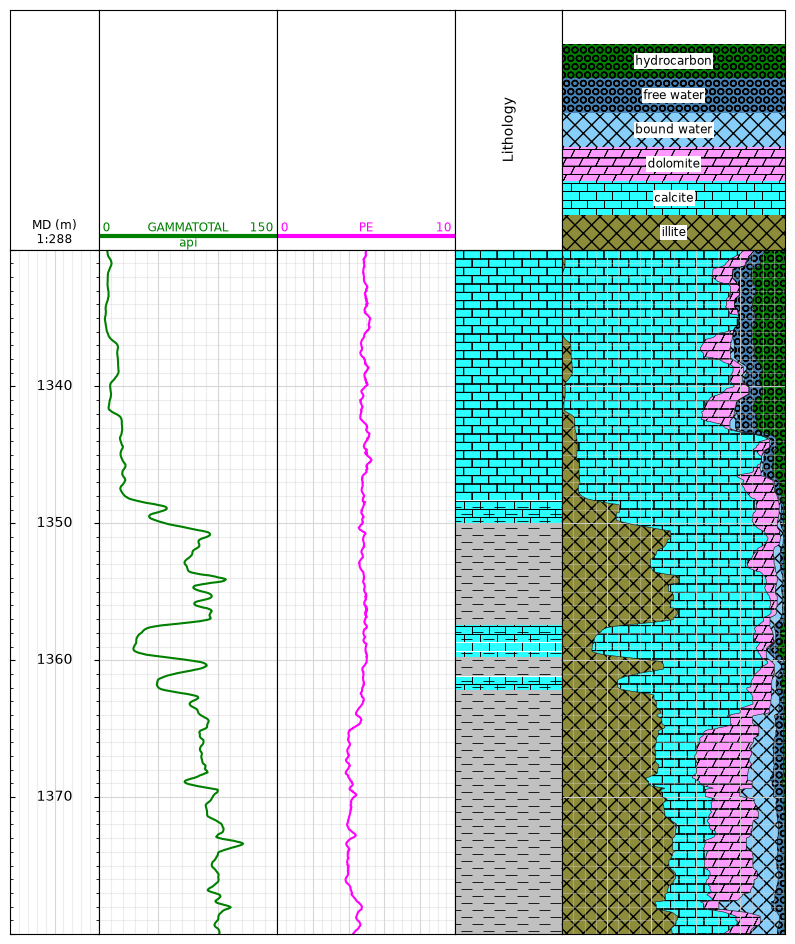

In [16]:
for number, (_, _, values) in enumerate(layers):
    cumulative = sum(v for _, _, v in layers[: number + 1])
    log.append_curve(f"VCUM{number}", cumulative.to_numpy(), unit="v/v")

view = WellView(
    log,
    ntrail=5,
    ncycle=7,
    label={"limit": (0, 70), "major": 10},
    depth={"limit": (1330.0, 1380.0), "major": 10, "minor": 1},
    widths=(1.0, 2.0, 2.0, 1.2, 2.5),
)
view.set(1, limit=(0, 150), major=50, minor=10)
view.set(2, limit=(0, 10), major=2, minor=0.5)
view.set(3, limit=(0, 1), major=1, minor=1, grid=False)
view.set(4, limit=(0, 1), major=0.2, minor=0.05)

figure = plt.figure(figsize=(10, 12))
view(figure)
view.add_depths(0)
view.add_curve(1, "GAMMATOTAL", color="green")
view.add_curve(2, "PE", color="magenta")

for top, base, name in zones:
    inside = (depth >= top) & (depth <= base)
    Pigment.fill_solid(view.stage(3), depth[inside], np.zeros(inside.sum()), 1.0, **Lithology[name])
view.label(3).text(0.5, 35, "Lithology", ha="center", va="center", rotation=90)

for number in range(len(layers)):
    view.add_curve(4, f"VCUM{number}", color="black", linewidth=0.4, cycle=False)
for number, (title, style, _) in enumerate(layers):
    left = None if number == 0 else number - 1  # None: the left edge of the track
    view.add_module(4, left=left, right=number, cycle=number, title=title, **style)

A key of the lithologies found, to go with the column:

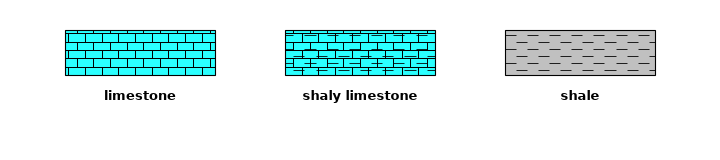

In [17]:
found = list(dict.fromkeys(name for _, _, name in zones))
fig = Lithology.plot_key(found, ncols=len(found), title="")

## 7. In a cross-section

Motifs work in any filled area, not only vertical tracks. `Pigment.add_motifs` tiles them inside the result of `fill_between`, which is how `CrossView.add_formation(name, **style)` shades formations between wells.

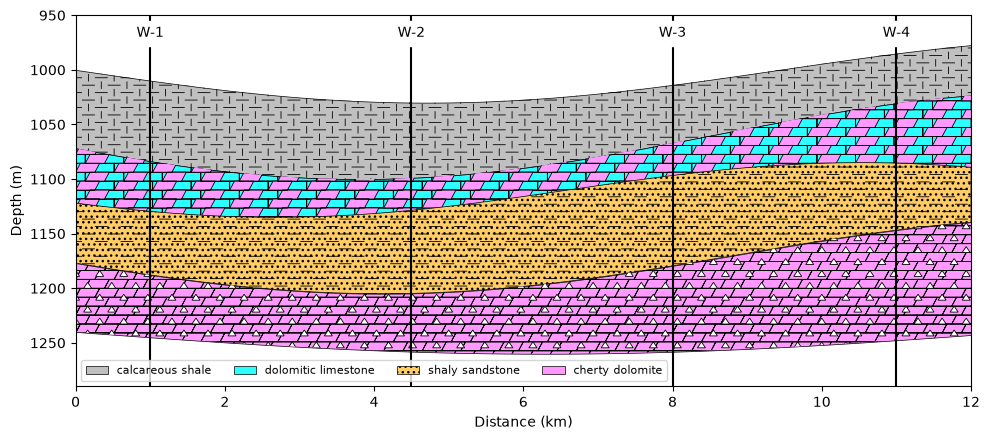

In [18]:
distance = np.linspace(0, 12, 200)  # km
surfaces = [
    1000 + 30 * np.sin(distance / 3),
    1060 + 40 * np.sin(distance / 3 + 0.3),
    1110 + 25 * np.sin(distance / 2.5 + 0.5),
    1170 + 35 * np.sin(distance / 3 + 0.2),
    1240 + 20 * np.sin(distance / 4),
]
names = ["calcareous shale", "dolomitic limestone", "shaly sandstone", "cherty dolomite"]

fig, axis = plt.subplots(figsize=(10, 4.5))
axis.set_xlim(0, 12)
axis.set_ylim(1290, 950)  # set the limits before filling: motifs are sized in points

for upper, lower, name in zip(surfaces, surfaces[1:], names):
    style = Lithology[name]
    fill = axis.fill_between(
        distance, upper, lower, facecolor=style.facecolor, hatch=style.hatch,
        edgecolor="black", linewidth=0.5, label=style.label,
    )
    Pigment.add_motifs(axis, fill, style.motifs)

for well, x in zip(["W-1", "W-2", "W-3", "W-4"], (1, 4.5, 8, 11)):
    axis.axvline(x, color="black", linewidth=1.5)
    axis.text(x, 960, well, ha="center", va="top", backgroundcolor="white")

axis.set_xlabel("Distance (km)")
axis.set_ylabel("Depth (m)")
axis.legend(loc="lower left", ncols=4, fontsize=8)
fig.tight_layout()

## Notes

- Motifs are converted with the axes' limits and size at the time of the fill, so set the limits (and figure size) first. `WellView` does this when it builds its tracks.
- Each motif is drawn as one clipped shape, so long intervals stay fast.
- Hatches are drawn in black; on dark face colours (e.g. `Porespace.liquid`) prefer a lighter colour or no hatch.